# 08. 계층적 에이전트 팀 (Hierarchical Agent Team)

> Supervisor도 부담을 느낄 만큼 큰 작업은 **팀 단위로 쪼개요**. Research Team / Doc Writing Team을 서브그래프로 만들어 Super-Supervisor가 조율하는 구조를 구현해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **계층적 멀티 에이전트** 구조가 필요한 이유를 설명하고, 단일 Supervisor와의 차이를 구분할 수 있어요
2. **Research Team**과 **Doc Writing Team**을 독립적인 서브그래프로 구성하고 각 팀에 특화된 도구를 연결할 수 있어요
3. **AgentFactory**, **create_team_supervisor**, **preprocess** 헬퍼 패턴을 사용해 에이전트 생성 코드를 재사용할 수 있어요
4. **Super-Graph**에서 파이프라인 연산자(`|`)로 서브그래프를 합성하고, `get_last_message`/`join_graph` 헬퍼로 상태를 변환할 수 있어요

## 사전 지식

- Part 09의 02-Supervisor, 03-Multi-Agent-Collaboration, 04-Multi-Agent-Supervisor 노트북
- StateGraph, 조건부 엣지, MemorySaver 사용법
- `create_agent` 및 `create_team_supervisor` 패턴
- 이전 노트북 `07-Skills-Pattern.ipynb`에서 배운 온디맨드 컨텍스트 로딩 개념

## 계층적 에이전트 팀이란?

이전 Supervisor 패턴에서는 **하나의 Supervisor**가 모든 작업자를 직접 관리했어요. 이 방식은 단순한 경우에 효율적이지만, 다음 상황에서는 한계가 생겨요.

| 문제 상황 | 설명 |
|-----------|------|
| **작업자 수 증가** | 작업자가 10개 이상이 되면 Supervisor의 컨텍스트 부담이 커져요 |
| **전문 영역 분리** | 웹 연구 vs 문서 작성처럼 완전히 다른 도구셋이 필요한 경우 |
| **독립적 서브워크플로** | 각 팀이 자체 루프를 가질 때 단일 그래프로 표현하기 어려워요 |

> 🎯 **강의 포인트**: 계층적 구조는 **대기업의 조직 체계**와 같아요. CEO(Top Supervisor)가 직원 100명을 직접 관리하면 엉망이 되죠. 대신 CEO → 부서장(Sub-Supervisor) → 팀원(Worker) 구조로 위임하면 효율적이에요. CEO는 "조사 부서에서 자료 모아오고, 집필 부서에서 보고서 써"라고만 지시하면 돼요. 각 부서 내부에서 누가 무엇을 할지는 부서장이 알아서 결정해요.

> 🔑 **핵심 개념**: 계층적 에이전트 팀은 **책임의 위임**이 핵심이에요. 최상위 감독자는 "어떤 팀이 할 것인지"만 결정하고, 팀 내부의 "어떻게 할 것인지"는 Sub-Supervisor가 결정해요.

이 노트북에서 구현할 시스템 구조를 살펴볼게요.

```mermaid
flowchart TD
    User(["사용자 요청<br/>User Request"]):::input
    
    subgraph SuperGraph["Super-Graph (최상위 그래프)"]
        TopSup["총 감독자<br/>Top Supervisor"]:::process
        
        subgraph ResearchTeam["Research Team"]
            RSup["Research Supervisor"]:::process
            Searcher["Searcher<br/>(TavilySearch)"]:::process
            Scraper["WebScraper<br/>(URL 스크래핑)"]:::process
            RSup -->|다음 작업자 선택| Searcher
            RSup -->|다음 작업자 선택| Scraper
            Searcher --> RSup
            Scraper --> RSup
        end
        
        subgraph DocTeam["Doc Writing Team"]
            DSup["Doc Supervisor"]:::process
            Writer["DocWriter<br/>(문서 작성/편집)"]:::process
            Note["NoteTaker<br/>(개요 작성)"]:::process
            Chart["ChartGenerator<br/>(차트 생성)"]:::process
            DSup -->|다음 작업자 선택| Writer
            DSup -->|다음 작업자 선택| Note
            DSup -->|다음 작업자 선택| Chart
            Writer --> DSup
            Note --> DSup
            Chart --> DSup
        end
        
        TopSup -->|ResearchTeam| ResearchTeam
        TopSup -->|PaperWritingTeam| DocTeam
        ResearchTeam --> TopSup
        DocTeam --> TopSup
        TopSup -->|FINISH| Done
    end
    
    User --> TopSup
    Done(["최종 결과<br/>Final Output"]):::output
    
    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
```

> 💡 **실무 팁**: 다이어그램에서 ResearchTeam 전체와 DocTeam 전체가 각각 하나의 "노드"처럼 Super-Graph에 연결되는 것을 주목하세요. 팀 내부의 복잡한 루프는 Super-Graph에서 완전히 숨겨져요. 이것이 계층적 설계의 핵심 장점인 **캡슐화(Encapsulation)**예요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 API 키를 읽어와요
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# 실행 흐름을 LangSmith에서 시각적으로 확인할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Hierarchical-Agent"

### 1-2. Research Team 도구

| 도구 | 설명 |
|------|------|
| `TavilySearch` | 최신 웹 검색 수행 (Tavily API) |
| `scrape_webpages` | URL 목록에서 전체 페이지 내용 스크래핑 |

> 💡 **실무 팁**: `TavilySearch`는 간결한 검색 결과를 반환하고, `scrape_webpages`는 특정 URL의 전체 내용을 가져와요. 두 도구를 조합하면 "검색 후 상세 조사" 워크플로를 구현할 수 있어요.

In [3]:
# ---------------------------------------------------
# Research Team 도구 정의
# ---------------------------------------------------
# TavilySearch: 웹 검색 도구 (Tavily API 키 필요)
# scrape_webpages: URL에서 HTML 본문 추출
from typing import List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain.tools import tool

# 최대 3개의 검색 결과를 반환하는 Tavily 검색 도구 (컨텍스트 폭주 방지)
tavily_tool = TavilySearch(max_results=3)


@tool
def scrape_webpages(urls: List[str]) -> str:
    """웹 페이지 스크래핑 도구

    주어진 URL 목록에서 웹 페이지 내용을 스크래핑합니다.
    검색 결과로 얻은 URL의 상세 내용을 가져올 때 사용해요.
    """
    # User-Agent를 설정해 일반 브라우저처럼 보이게 해요
    loader = WebBaseLoader(
        web_path=urls,
        header_template={
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/102.0.0.0 Safari/537.36"
            ),
        },
    )
    docs = loader.load()

    # 각 문서를 XML 블록으로 감싸서 반환해요.
    # 컨텍스트 폭주를 막으려고 본문은 최대 3000자까지만 사용해요.
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content[:3000]}\n</Document>'
            for doc in docs
        ]
    )


print("Research Team 도구 정의 완료:", [tavily_tool.name, scrape_webpages.name])

USER_AGENT environment variable not set, consider setting it to identify your requests.


Research Team 도구 정의 완료: ['tavily_search', 'scrape_webpages']


### 1-2. Doc Writing Team 도구

문서 작성 팀은 파일 시스템에 접근하는 도구를 사용해요.

| 도구 | 기능 |
|------|------|
| `create_outline` | 개요(아웃라인)를 파일로 저장 |
| `write_document` | 새 문서 작성 및 저장 |
| `read_document` | 저장된 문서 읽기 (부분 읽기 지원) |
| `edit_document` | 특정 줄 번호에 텍스트 삽입 |
| `PythonREPLTool` | Python 코드 실행 (차트 생성 등) |

> ⚠️ **자주 하는 실수**: `WORKING_DIRECTORY`를 설정하지 않으면 에이전트가 파일을 저장할 위치를 모를 수 있어요. 반드시 작업 디렉토리를 명시적으로 만들어 주세요.

In [4]:
# ---------------------------------------------------
# Doc Writing Team 도구 정의
# ---------------------------------------------------
# 파일 시스템 접근 도구를 정의해요
# 모든 파일은 WORKING_DIRECTORY 아래에 저장돼요
from pathlib import Path
from typing import Dict, Optional
from typing_extensions import Annotated

# 작업 디렉토리 생성 (없으면 자동 생성)
WORKING_DIRECTORY = Path("./tmp")
WORKING_DIRECTORY.mkdir(exist_ok=True)


@tool
def create_outline(
    points: Annotated[List[str], "문서의 주요 섹션 목록"],
    file_name: Annotated[str, "저장할 파일명"],
) -> Annotated[str, "저장된 파일 경로"]:
    """아웃라인(개요) 생성 도구

    번호가 매겨진 목차를 파일로 저장합니다.
    """
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")  # 1부터 번호 매기기
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "읽을 파일명"],
    start: Annotated[Optional[int], "시작 줄 번호 (기본값: 0)"] = None,
    end: Annotated[Optional[int], "종료 줄 번호 (기본값: 끝까지)"] = None,
) -> str:
    """문서 읽기 도구

    파일 전체 또는 지정된 범위의 줄을 읽어 반환합니다.
    """
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "작성할 텍스트 내용"],
    file_name: Annotated[str, "저장할 파일명"],
) -> Annotated[str, "저장된 파일 경로"]:
    """문서 작성 도구

    텍스트 내용을 지정된 파일로 저장합니다.
    """
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "편집할 파일명"],
    inserts: Annotated[
        Dict[int, str],
        "줄 번호(1부터 시작) → 삽입할 텍스트 딕셔너리",
    ],
) -> Annotated[str, "편집된 파일 경로"]:
    """문서 편집 도구

    지정된 줄 번호에 텍스트를 삽입하여 문서를 업데이트합니다.
    """
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    # 줄 번호 순으로 정렬 후 삽입 (뒤에서부터 처리하면 인덱스 오염 없이 안전해요)
    for line_number, text in sorted(inserts.items()):
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line {line_number} out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


# Doc Writing Team 도구 정의 완료

In [5]:
# !uv add langchain_experimental

In [6]:
# ---------------------------------------------------
# Python REPL 도구 초기화
# ---------------------------------------------------
# ChartGenerator 에이전트가 matplotlib 등으로 차트를 생성할 때 사용해요
from langchain_experimental.tools import PythonREPLTool

python_repl_tool = PythonREPLTool()
# Python REPL 도구 초기화 완료

## 2. 유틸리티 함수 및 헬퍼 정의

에이전트 팀을 효율적으로 구축하기 위한 재사용 가능한 컴포넌트를 정의해요.

### 2-1. AgentFactory 클래스

동일한 LLM 설정으로 여러 에이전트를 만들 때 코드 중복을 줄여주는 팩토리 패턴이에요.

> 🔑 **핵심 개념**: `create_agent_node`는 에이전트의 반환값을 `HumanMessage`로 감싸서 반환해요. 이렇게 하면 어떤 팀 멤버가 메시지를 남겼는지 `name` 필드로 추적할 수 있어요.

In [7]:
# ---------------------------------------------------
# AgentFactory 클래스 정의
# ---------------------------------------------------
# 동일한 LLM으로 여러 에이전트를 생성할 때 팩토리 패턴을 사용해요
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.messages import HumanMessage


class AgentFactory:
    """에이전트 팩토리 클래스

    하나의 LLM 설정으로 여러 에이전트와 노드 함수를 생성해요.
    """

    def __init__(self, model_name: str):
        """초기화 - 모델명으로 LLM 인스턴스를 생성해요.

        Args:
            model_name: "openai:gpt-4o-mini" 형식의 모델 식별자
        """
        # temperature=0: 일관된 출력을 위해 무작위성을 최소화해요
        self.llm = init_chat_model(model_name, temperature=0)

    def create_agent_node(self, agent, name: str):
        """에이전트를 StateGraph 노드 함수로 변환해요.

        Args:
            agent: create_agent()로 생성한 에이전트 인스턴스
            name:  메시지 name 필드에 기록될 에이전트 이름

        Returns:
            state를 받아 {"messages": [...]} 딕셔너리를 반환하는 노드 함수
        """

        def agent_node(state):
            # 하위 에이전트에게는 **가장 최근 요청 메시지만** 전달해요.
            # 상위 state를 통째로 넘기면 메시지가 누적되어 컨텍스트 폭주가 발생해요.
            last_msg = state["messages"][-1]
            result = agent.invoke({"messages": [last_msg]})
            return {
                "messages": [
                    HumanMessage(
                        content=result["messages"][-1].content,
                        name=name,  # 어떤 에이전트가 남긴 메시지인지 기록해요
                    )
                ]
            }

        return agent_node


# gpt-4o-mini 기반 팩토리 인스턴스 생성
# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 더 강력한 모델이 필요하면: "openai:gpt-4o" 로 변경하세요
agent_factory = AgentFactory("openai:gpt-4o-mini")
# AgentFactory 준비 완료 (openai:gpt-4o-mini)

### 2-2. create_team_supervisor 함수

팀 감독자(Sub-Supervisor)를 생성하는 핵심 함수예요. 이 함수가 반환하는 체인은 `RouteResponse`라는 구조화된 출력으로 다음 작업자를 선택해요.

> 🎯 **강의 포인트**: `Literal[*options_for_next]`를 사용하면 Pydantic이 허용된 값만 받도록 강제해요. LLM이 임의의 문자열을 반환할 수 없어서 라우팅이 훨씬 안정적이에요.

In [8]:
# ---------------------------------------------------
# create_team_supervisor: 팀 감독자 체인 생성 함수
# ---------------------------------------------------
# FINISH 또는 팀 멤버 중 하나를 선택하는 Supervisor 체인을 반환해요
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel
from typing import Literal


def create_team_supervisor(model_name: str, system_prompt: str, members: list) -> str:
    """팀 감독자(Sub-Supervisor) 체인을 생성해요.

    Args:
        model_name:    사용할 LLM 모델 식별자
        system_prompt: Supervisor의 역할과 규칙을 정의하는 시스템 프롬프트
        members:       관리할 팀 멤버 이름 목록

    Returns:
        prompt | llm.with_structured_output(RouteResponse) 체인
    """
    # 선택 가능한 옵션: FINISH + 모든 멤버 이름
    options_for_next = ["FINISH"] + members

    # RouteResponse: 허용된 값만 받는 Pydantic 모델
    # Literal[*options_for_next]가 LLM 출력을 제한해요
    class RouteResponse(BaseModel):
        next: Literal[*options_for_next]

    # 프롬프트 구성: system → 대화 히스토리 → 라우팅 지시
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "human",
                "Given the conversation above, who should act next? "
                "Or should we FINISH? If the requested tasks have been completed, "
                "you MUST select FINISH. Do NOT repeat completed tasks. "
                "Select one of: {options}",
            ),
        ]
    ).partial(options=str(options_for_next))

    # 구조화된 출력을 사용해 안정적인 라우팅을 구현해요
    llm = init_chat_model(model_name, temperature=0)
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)

    return supervisor_chain


# create_team_supervisor 함수 정의 완료

## 3. Research Team 구성

Research Team은 **Searcher**와 **WebScraper** 두 작업자와 **Research Supervisor**로 구성돼요.

```mermaid
flowchart LR
    START([시작]):::input
    RSup["Research Supervisor"]:::process
    Searcher["Searcher<br>(TavilySearch)"]:::process
    Scraper["WebScraper<br>(scrape_webpages)"]:::process
    END_NODE(["END"]):::output

    START --> RSup
    RSup -->|Searcher 선택| Searcher
    RSup -->|WebScraper 선택| Scraper
    RSup -->|FINISH| END_NODE
    Searcher --> RSup
    Scraper --> RSup

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
```

In [9]:
# ---------------------------------------------------
# Research Team 상태(State) 정의
# ---------------------------------------------------
# add_messages 리듀서: 메시지가 덮어쓰이지 않고 누적돼요
from typing import List, TypedDict
from typing_extensions import Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class ResearchTeamState(TypedDict):
    """Research Team의 공유 상태

    Attributes:
        messages:     팀 멤버 간 공유되는 메시지 히스토리
        team_members: 팀 멤버 이름 목록 (Supervisor 프롬프트에서 참조)
        next:         Supervisor가 선택한 다음 작업자
    """

    messages: Annotated[List[BaseMessage], add_messages]
    team_members: List[str]
    next: str


# ResearchTeamState 정의 완료

In [10]:
# ---------------------------------------------------
# Research Team 에이전트 및 Supervisor 생성
# ---------------------------------------------------
# 각 에이전트는 특화된 도구만 사용해요

# gpt-4o-mini 기반 LLM (Research Team용)
research_llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# Searcher: TavilySearch로 웹 검색만 담당
# 파일 저장 환각을 막기 위해 시스템 프롬프트로 역할을 엄격히 제한해요
search_agent = create_agent(
    research_llm,
    tools=[tavily_tool],
    system_prompt=(
        "당신은 웹 검색 전문가예요. tavily_search 도구로 주제를 조사해서 "
        "핵심 내용 3~5문장으로 요약만 반환하세요. "
        "파일 저장, 보고서 작성, report.md 생성 같은 건 절대 하지 않고, "
        "'저장했습니다'나 '생성했습니다' 같은 말도 하지 마세요."
    ),
)
search_node = agent_factory.create_agent_node(search_agent, name="Searcher")

# WebScraper: URL에서 상세 내용 추출만 담당
web_scraping_agent = create_agent(
    research_llm,
    tools=[scrape_webpages],
    system_prompt=(
        "당신은 URL 스크래핑 전문가예요. scrape_webpages 도구로 페이지 내용을 "
        "추출해서 요약만 반환하세요. 파일 저장이나 보고서 작성은 하지 않습니다."
    ),
)
web_scraping_node = agent_factory.create_agent_node(
    web_scraping_agent, name="WebScraper"
)

# Research Supervisor: Searcher와 WebScraper 중 누가 다음인지 결정
# 컨텍스트 폭주를 막기 위해 각 워커는 최대 1번만 호출하고 결과가 나오면 즉시 FINISH
research_supervisor = create_team_supervisor(
    "openai:gpt-4o-mini",
    "You are a supervisor tasked with managing a conversation between the "
    "following workers: Searcher, WebScraper. Given the following user request, "
    "respond with the worker to act next. Each worker will perform a task and "
    "respond with their results and status. "
    "\n\nRULES:\n"
    "1. Call each worker AT MOST ONCE. Do NOT call the same worker twice.\n"
    "2. For a typical research request, one Searcher call is enough - then FINISH.\n"
    "3. Only call WebScraper if detailed content from specific URLs is required.\n"
    "4. Once you have any search results, respond with FINISH immediately.",
    ["Searcher", "WebScraper"],
)

# Research Team 에이전트 생성 완료

In [11]:
# ---------------------------------------------------
# Research Team 그래프 생성 및 컴파일
# ---------------------------------------------------
# 라우팅 함수: Supervisor의 next 값을 반환해요
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


def get_next_node(state):
    """상태에서 다음 노드 이름을 반환하는 라우팅 함수"""
    return state["next"]


# Research Team 그래프 구성
web_research_graph = StateGraph(ResearchTeamState)

# 노드 등록
web_research_graph.add_node("Searcher", search_node)
web_research_graph.add_node("WebScraper", web_scraping_node)
web_research_graph.add_node("Supervisor", research_supervisor)

# 작업자 → Supervisor: 작업 완료 후 반드시 Supervisor에게 보고
web_research_graph.add_edge("Searcher", "Supervisor")
web_research_graph.add_edge("WebScraper", "Supervisor")

# Supervisor → 다음 노드: 조건부 라우팅
web_research_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {"Searcher": "Searcher", "WebScraper": "WebScraper", "FINISH": END},
)

# 진입점: Supervisor부터 시작해요
web_research_graph.set_entry_point("Supervisor")

# 컴파일: MemorySaver로 체크포인트 저장
web_research_app = web_research_graph.compile(checkpointer=MemorySaver())

# Research Team 그래프 컴파일 완료

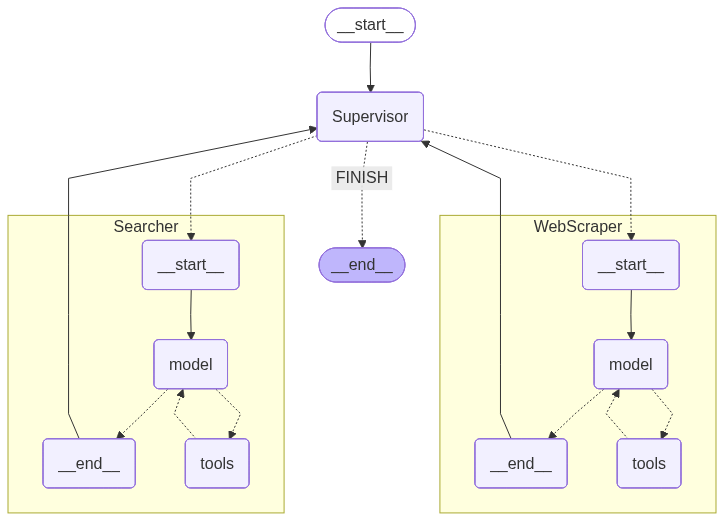

In [12]:
# ---------------------------------------------------
# Research Team 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → Supervisor → (Searcher | WebScraper | END) → Supervisor → ...
# Supervisor: RouteResponse로 다음 워커를 선택하거나 FINISH로 종료해요
# Searcher: TavilySearch로 웹 검색을 수행해요
# WebScraper: URL에서 상세 내용을 스크래핑해요
from IPython.display import Image, display

# xray=True로 서브그래프 내부까지 시각화해요
display(Image(web_research_app.get_graph(xray=True).draw_mermaid_png()))

## 4. Doc Writing Team 구성

Doc Writing Team은 **NoteTaker(개요 작성)→DocWriter(내용 작성)→ChartGenerator(차트 생성)→DocWriter(최종 저장)** 순서로 동작해요.

### 상태 전처리(preprocess) 패턴

에이전트가 현재 작업 디렉토리에 어떤 파일이 있는지 알아야 이어서 작업할 수 있어요. `preprocess` 함수를 파이프라인 연산자(`|`)로 에이전트 앞에 연결하면 상태를 자동으로 보강할 수 있어요.

> 🔑 **핵심 개념**: `preprocess | agent` 패턴에서 `preprocess`가 반환한 딕셔너리가 에이전트의 입력이 돼요. 이는 LangChain의 LCEL(LangChain Expression Language) 파이프라인 합성 방식이에요.

In [13]:
# ---------------------------------------------------
# Doc Writing Team 상태 및 전처리 함수 정의
# ---------------------------------------------------
# current_files: 에이전트가 파일 목록을 인식할 수 있게 해주는 추가 상태 필드


class DocWritingTeamState(TypedDict):
    """Doc Writing Team의 공유 상태

    Attributes:
        messages:      팀 멤버 간 공유되는 메시지 히스토리
        team_members:  팀 멤버 이름 목록
        next:          다음 작업자
        current_files: 작업 디렉토리 내 현재 파일 목록 (전처리로 주입)
    """

    messages: Annotated[List[BaseMessage], add_messages]
    team_members: str
    next: str
    current_files: str


def preprocess(state: DocWritingTeamState) -> DocWritingTeamState:
    """상태 전처리 함수

    작업 디렉토리의 파일 목록을 상태에 추가해요.
    에이전트가 이미 작성된 파일을 인식하고 이어서 작업할 수 있게 해줘요.
    """
    written_files = []
    try:
        # WORKING_DIRECTORY 아래의 모든 파일을 재귀적으로 검색해요
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except Exception:
        pass

    if not written_files:
        return {**state, "current_files": "No files written yet."}

    # 파일 목록을 사람이 읽기 쉬운 형태로 상태에 주입해요
    return {
        **state,
        "current_files": "\nBelow are files your team has written:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }


# DocWritingTeamState 및 preprocess 정의 완료

In [14]:
# ---------------------------------------------------
# Doc Writing Team 에이전트 생성
# ---------------------------------------------------
# 각 에이전트 앞에 preprocess를 파이프라인으로 연결해요
# preprocess | agent: 상태를 보강한 후 에이전트에 전달하는 패턴

doc_llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# DocWriter: 문서 작성 및 편집 전문
doc_writer_agent = create_agent(
    doc_llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        "You are an expert document writer. "
        "Your mission is to write detailed, well-structured documents on given topics."
    ),
)
# preprocess | agent: 파일 목록을 인식한 상태로 에이전트 실행
context_aware_doc_writer = preprocess | doc_writer_agent
doc_writing_node = agent_factory.create_agent_node(
    context_aware_doc_writer, name="DocWriter"
)

# NoteTaker: 개요(아웃라인) 작성 전문
note_taking_agent = create_agent(
    doc_llm,
    tools=[create_outline, read_document],
    system_prompt=(
        "You are an expert in creating structured outlines for documents. "
        "Your mission is to create a clear, logical outline for the given topic."
    ),
)
context_aware_note_taker = preprocess | note_taking_agent
note_taking_node = agent_factory.create_agent_node(
    context_aware_note_taker, name="NoteTaker"
)

# ChartGenerator: Python으로 차트 생성 전문
chart_agent = create_agent(
    doc_llm,
    tools=[read_document, python_repl_tool],
    system_prompt=(
        "You are an expert data visualization specialist. "
        "Your mission is to create informative charts and visualizations "
        "using Python to complement the document content."
    ),
)
context_aware_chart_generator = preprocess | chart_agent
chart_generating_node = agent_factory.create_agent_node(
    context_aware_chart_generator, name="ChartGenerator"
)

# Doc Writing Team Supervisor: 3명의 작업자를 관리
# 워크플로우 순서를 명시해 무한 루프를 방지해요
doc_writing_supervisor = create_team_supervisor(
    "openai:gpt-4o-mini",
    "You are a supervisor tasked with managing a conversation between the "
    "following workers: DocWriter, NoteTaker, ChartGenerator. "
    "Given the following user request, respond with the worker to act next. "
    "Each worker will perform a task and respond with their results and status. "
    "When finished, respond with FINISH. "
    "\n\nWORKFLOW: NoteTaker(outline) -> DocWriter(content) -> "
    "ChartGenerator(if needed) -> DocWriter(save) -> FINISH. "
    "Once the document is saved, respond with FINISH immediately. "
    "Do NOT repeat any step that has already been completed.",
    ["DocWriter", "NoteTaker", "ChartGenerator"],
)

# Doc Writing Team 에이전트 생성 완료

In [15]:
# ---------------------------------------------------
# Doc Writing Team 그래프 생성 및 컴파일
# ---------------------------------------------------
authoring_graph = StateGraph(DocWritingTeamState)

# 노드 등록
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("ChartGenerator", chart_generating_node)
authoring_graph.add_node("Supervisor", doc_writing_supervisor)

# 작업자 → Supervisor
authoring_graph.add_edge("DocWriter", "Supervisor")
authoring_graph.add_edge("NoteTaker", "Supervisor")
authoring_graph.add_edge("ChartGenerator", "Supervisor")

# Supervisor → 다음 작업자 (조건부 라우팅)
authoring_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "ChartGenerator": "ChartGenerator",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("Supervisor")
authoring_app = authoring_graph.compile(checkpointer=MemorySaver())

# Doc Writing Team 그래프 컴파일 완료

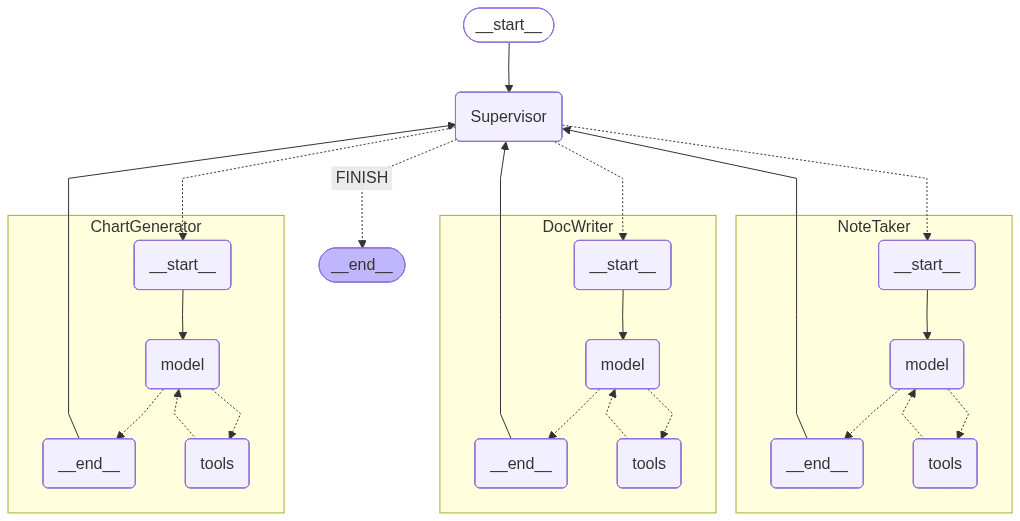

In [16]:
# 그래프 흐름: START → Supervisor → (DocWriter | NoteTaker | ChartGenerator | END) → Supervisor → ...
# Supervisor: 워크플로우 순서(NoteTaker→DocWriter→ChartGenerator→DocWriter)에 따라 작업을 분배해요
# NoteTaker: 문서 개요(아웃라인)를 작성해요
# DocWriter: 문서 내용을 작성하고 파일로 저장해요
# ChartGenerator: Python REPL로 차트를 생성해요
# preprocess | agent: 파일 목록을 상태에 주입하여 에이전트가 이전 작업을 인식해요
from IPython.display import Image, display
display(Image(authoring_app.get_graph(xray=True).draw_mermaid_png()))

## 5. Super-Graph 구성: 계층 최상위 조립

이제 두 팀을 합쳐 Super-Graph를 만들 차례예요. 핵심은 **파이프라인 연산자(`|`)로 서브그래프를 합성**하는 패턴이에요.

```python
super_graph.add_node(
    "ResearchTeam",
    get_last_message | web_research_app | join_graph
)
```

이 코드는 세 단계를 파이프라인으로 연결해요:

| 단계 | 함수 | 역할 | 비유 |
|------|------|------|------|
| 1 | `get_last_message` | Super-Graph 상태에서 마지막 메시지만 추출 | 업무 지시서를 팀에게 전달 |
| 2 | `web_research_app` | Research Team 서브그래프 실행 | 팀 내부에서 작업 수행 |
| 3 | `join_graph` | 서브그래프 결과에서 마지막 메시지를 Super-Graph 상태로 병합 | 팀 결과 보고서를 CEO에게 올림 |

> 🔑 **핵심 개념**: `get_last_message`와 `join_graph`는 **상태 타입 변환 어댑터**예요. Super-Graph의 `SuperGraphState`와 서브그래프의 `ResearchTeamState`는 서로 다른 타입이에요. 이 두 함수가 타입 불일치를 자동으로 해결해주는 다리(bridge) 역할을 해요. 이 패턴을 기억하면 어떤 서브그래프도 Super-Graph에 쉽게 연결할 수 있어요.

> ⚠️ **자주 하는 실수**: 서브그래프를 Super-Graph에 직접 연결하면 상태 타입이 맞지 않아 에러가 발생해요. 반드시 `get_last_message | subgraph | join_graph` 3단계 파이프라인을 사용하세요.

In [17]:
# ---------------------------------------------------
# Super-Graph 상태 및 어댑터 함수 정의
# ---------------------------------------------------
# get_last_message: Super-Graph → 서브그래프 상태 변환
# join_graph:       서브그래프 결과 → Super-Graph 상태 병합
from operator import add
import uuid


class SuperGraphState(TypedDict):
    """Super-Graph의 최상위 상태

    Attributes:
        messages: 전체 대화 히스토리
        next:     총 감독자가 선택한 다음 팀
        completed_teams: 이미 실행한 팀 목록
    """

    messages: Annotated[List[BaseMessage], add_messages]
    next: str
    completed_teams: Annotated[List[str], add]


def get_last_message(state: SuperGraphState) -> dict:
    """Super-Graph 상태에서 마지막 메시지를 추출해요.

    서브그래프는 자체 상태 타입을 가지므로
    Super-Graph 상태를 서브그래프 입력 형식으로 변환해야 해요.
    """
    last_msg = state["messages"][-1]
    if isinstance(last_msg, str):
        return {"messages": [HumanMessage(content=last_msg)]}
    # AIMessage, HumanMessage 등 모든 메시지 타입 처리
    return {"messages": [HumanMessage(content=last_msg.content)]}


def get_original_request(state: SuperGraphState) -> str:
    """최초 사용자 요청을 찾아 반환해요."""
    for message in state["messages"]:
        if isinstance(message, HumanMessage) and not getattr(message, "name", None):
            return message.content
    first = state["messages"][0]
    return first if isinstance(first, str) else first.content


def join_graph(response: dict) -> dict:
    """서브그래프 실행 결과를 Super-Graph 상태로 병합해요.

    서브그래프의 마지막 메시지만 추출하여 Super-Graph에 전달해요.
    """
    # 서브그래프 결과에서 마지막 메시지를 꺼내 반환해요
    return {"messages": [response["messages"][-1]]}


def build_team_input(state: SuperGraphState, team_name: str) -> dict:
    """팀이 원 요청과 이전 팀 결과를 함께 볼 수 있게 입력 메시지를 구성해요."""
    original_request = get_original_request(state)
    latest_content = state["messages"][-1].content
    if team_name == "PaperWritingTeam" and latest_content != original_request:
        return {
            "messages": [
                HumanMessage(
                    content=(
                        f"원래 사용자 요청:\n{original_request}\n\n"
                        f"ResearchTeam 결과:\n{latest_content}\n\n"
                        "위 조사 결과를 바탕으로 원래 요청의 파일 작성 요구를 완료하세요."
                    )
                )
            ]
        }
    return get_last_message(state)


def subgraph_config() -> dict:
    """체크포인터가 있는 서브그래프 실행에 필요한 thread_id를 생성해요."""
    return {"configurable": {"thread_id": str(uuid.uuid4())}}


def call_research_team(state: SuperGraphState) -> dict:
    """ResearchTeam 서브그래프 실행 후 완료 상태를 기록해요."""
    response = web_research_app.invoke(
        build_team_input(state, "ResearchTeam"),
        config=subgraph_config(),
    )
    joined = join_graph(response)
    return {**joined, "completed_teams": ["ResearchTeam"]}


def call_paper_writing_team(state: SuperGraphState) -> dict:
    """PaperWritingTeam 서브그래프 실행 후 완료 상태를 기록해요."""
    response = authoring_app.invoke(
        build_team_input(state, "PaperWritingTeam"),
        config=subgraph_config(),
    )
    joined = join_graph(response)
    return {**joined, "completed_teams": ["PaperWritingTeam"]}


# SuperGraphState 및 어댑터 함수 정의 완료

In [18]:
# ---------------------------------------------------
# 총 감독자(Top Supervisor) 생성
# ---------------------------------------------------
# ResearchTeam과 PaperWritingTeam 중 하나를 선택해요
# 파일 작성 요구는 ResearchTeam 결과만으로 완료하지 않도록 완료 팀 목록을 함께 확인해요

def top_supervisor(state: SuperGraphState) -> dict:
    """최상위 라우터: 원 요청과 완료 팀 목록을 기준으로 다음 팀을 결정해요."""
    completed = set(state.get("completed_teams", []))
    original_request = get_original_request(state)
    request_lower = original_request.lower()

    needs_research = any(
        keyword in request_lower
        for keyword in ["검색", "조사", "research", "web", "최신"]
    )
    needs_file_output = any(
        keyword in request_lower
        for keyword in ["report.md", "저장", "보고서", "문서", "작성", "file", "document"]
    )

    if needs_research and "ResearchTeam" not in completed:
        return {"next": "ResearchTeam"}
    if needs_file_output and "PaperWritingTeam" not in completed:
        return {"next": "PaperWritingTeam"}
    return {"next": "FINISH"}


# 총 감독자 생성 완료

In [19]:
# ---------------------------------------------------
# Super-Graph 조립 및 컴파일
# ---------------------------------------------------
# 핵심 패턴: get_last_message | subgraph_app | join_graph
# 이 파이프라인이 상태 타입 변환을 자동으로 처리해줘요

super_graph_builder = StateGraph(SuperGraphState)

# 팀 노드: 원 요청과 팀 결과를 함께 전달하고, 완료 팀 목록을 기록해요
super_graph_builder.add_node("ResearchTeam", call_research_team)
super_graph_builder.add_node("PaperWritingTeam", call_paper_writing_team)
super_graph_builder.add_node("Supervisor", top_supervisor)

# 팀 → 총 감독자: 팀 작업 완료 후 보고
super_graph_builder.add_edge("ResearchTeam", "Supervisor")
super_graph_builder.add_edge("PaperWritingTeam", "Supervisor")

# 총 감독자 → 다음 팀 또는 종료
super_graph_builder.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {
        "ResearchTeam": "ResearchTeam",
        "PaperWritingTeam": "PaperWritingTeam",
        "FINISH": END,
    },
)

# 진입점: 총 감독자
super_graph_builder.set_entry_point("Supervisor")

# 컴파일
super_graph = super_graph_builder.compile(checkpointer=MemorySaver())

# Super-Graph 컴파일 완료

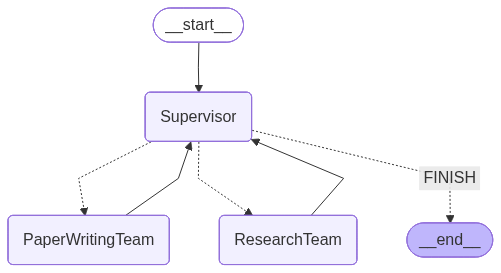

In [20]:
# ---------------------------------------------------
# Super-Graph 시각화
# ---------------------------------------------------
# 그래프 흐름: START → Supervisor → (ResearchTeam | PaperWritingTeam | END) → Supervisor → ...
# Supervisor(총 감독자): ResearchTeam과 PaperWritingTeam 중 다음 팀을 선택해요
# ResearchTeam: 웹 검색 + 스크래핑으로 자료를 수집해요 (내부 Supervisor 포함)
# PaperWritingTeam: 개요 작성 + 문서 작성 + 차트 생성해요 (내부 Supervisor 포함)
# get_last_message | subgraph | join_graph: 상태 타입 변환 어댑터 패턴이에요
from IPython.display import Image, display
display(Image(super_graph.get_graph().draw_mermaid_png()))

## 6. 헬퍼 함수 및 실행

그래프를 실행하고 결과를 출력하는 헬퍼 함수를 정의할게요.

In [21]:
# ---------------------------------------------------
# 그래프 실행 헬퍼 함수
# ---------------------------------------------------
# run_graph: 그래프 실행 후 스트리밍 출력 + 최종 상태 반환
import uuid
from langchain_core.runnables import RunnableConfig


def run_graph(app, message: str, recursive_limit: int = 50):
    """그래프를 실행하고 결과를 출력하는 헬퍼 함수

    Args:
        app:             컴파일된 StateGraph 앱
        message:         사용자 입력 메시지
        recursive_limit: 무한 루프 방지를 위한 최대 반복 횟수

    Returns:
        그래프 최종 상태 딕셔너리
    """
    # thread_id: 각 실행을 독립된 대화 세션으로 구분해요
    config = RunnableConfig(
        recursion_limit=recursive_limit,
        configurable={"thread_id": str(uuid.uuid4())},
    )

    inputs = {"messages": [HumanMessage(content=message)]}

    print(f"실행 시작: recursive_limit={recursive_limit}\n")
    # ============================================================

    # stream_mode="updates": 각 노드 실행 후 변경된 상태만 출력해요
    for chunk in app.stream(inputs, config, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            print(f"\n[{node_name}]")
            if isinstance(node_output, dict) and "messages" in node_output:
                last_msg = node_output["messages"][-1]
                if hasattr(last_msg, "content") and last_msg.content:
                    # 긴 출력은 200자로 잘라서 보여줘요
                    preview = last_msg.content[:200]
                    print(f"  {preview}{'...' if len(last_msg.content) > 200 else ''}")
            elif isinstance(node_output, dict) and "next" in node_output:
                print(f"  → 다음 노드: {node_output['next']}")

    # ============================================================
    # 실행 완료

    return app.get_state(config).values


# run_graph 헬퍼 함수 정의 완료

### 6-1. Research Team 단독 실행 테스트

먼저 Research Team만 독립적으로 실행해서 동작을 확인해요.

> 🎯 **강의 포인트**: 각 팀을 먼저 단독으로 테스트한 뒤 Super-Graph에 연결하는 것이 좋은 개발 전략이에요. 문제가 발생했을 때 어느 계층에서 발생했는지 바로 알 수 있어요.

In [22]:
# ---------------------------------------------------
# Research Team 단독 실행 테스트
# ---------------------------------------------------
# Research Team이 웹 검색 및 스크래핑을 올바르게 수행하는지 확인해요
# 주의: TavilySearch API 키가 필요해요 (TAVILY_API_KEY 환경 변수)

research_output = run_graph(
    web_research_app,
    "LangGraph 멀티 에이전트 패턴에 대해 웹에서 최신 정보를 검색해줘.",
    recursive_limit=20,
)

# === Research Team 최종 결과 ===
print(research_output["messages"][-1].content[:500])

실행 시작: recursive_limit=20


[Supervisor]
  → 다음 노드: Searcher

[Searcher]
  LangGraph의 멀티 에이전트 패턴은 여러 에이전트 간의 상호작용을 통해 복잡한 작업을 효율적으로 처리하는 방법을 제공합니다. 주요 패턴으로는 순차 처리 파이프라인과 조건부 분기 라우팅이 있으며, 각 에이전트는 이전 에이전트의 결과를 이어받아 작업을 수행합니다. 또한, 핸드오프 패턴을 통해 한 에이전트가 다른 에이전트에게 제어권을 넘기고 필요한 정보를 ...

[Supervisor]
  → 다음 노드: FINISH
LangGraph의 멀티 에이전트 패턴은 여러 에이전트 간의 상호작용을 통해 복잡한 작업을 효율적으로 처리하는 방법을 제공합니다. 주요 패턴으로는 순차 처리 파이프라인과 조건부 분기 라우팅이 있으며, 각 에이전트는 이전 에이전트의 결과를 이어받아 작업을 수행합니다. 또한, 핸드오프 패턴을 통해 한 에이전트가 다른 에이전트에게 제어권을 넘기고 필요한 정보를 전달할 수 있습니다. 이러한 구조는 에이전트 간의 명확한 역할 분담을 통해 시스템의 신뢰성을 높이고 개발 시간을 단축시키는 데 기여합니다.


### 6-2. Super-Graph 전체 실행

이제 Research Team과 Doc Writing Team을 모두 활용하는 전체 워크플로를 실행해요.

In [23]:
# ---------------------------------------------------
# Super-Graph 전체 실행
# ---------------------------------------------------
# 복잡한 연구 + 문서 작성 작업을 계층적으로 수행해요
# recursive_limit=15: 무한 루프 방지 (너무 크게 설정하면 비용이 높아져요)
# 실습용: 빠른 완주를 위해 단순한 요청을 사용해요 (실제로는 더 복잡한 주제도 가능)

output = run_graph(
    super_graph,
    """주제: LangGraph 멀티 에이전트 설계 패턴

작업 요청:
1. ResearchTeam이 "LangGraph multi-agent supervisor pattern"로 간단히 웹 검색해줘 (1회 검색으로 충분, 스크래핑은 건너뛰어도 돼)
2. 그 다음 PaperWritingTeam이 수집된 내용을 바탕으로 한글 요약 보고서를 작성하고 report.md로 저장해줘
   - 보고서: 3-4 문장의 짧은 요약으로 작성해줘""",
    recursive_limit=15,
)

실행 시작: recursive_limit=15


[Supervisor]
  → 다음 노드: ResearchTeam

[ResearchTeam]
  LangGraph 멀티 에이전트 감독 패턴은 LangGraph를 사용하여 계층적 멀티 에이전트 시스템을 구축하는 데 도움을 주는 파이썬 라이브러리입니다. 이 시스템에서는 전문화된 에이전트들이 중앙 감독 에이전트의 조정 하에 작동하며, 감독 에이전트는 통신 흐름과 작업 위임을 관리합니다. 이를 통해 개발자는 다양한 에이전트를 효과적으로 관리하고, 사용자 요청...

[Supervisor]
  → 다음 노드: PaperWritingTeam

[PaperWritingTeam]
  요청하신 내용을 바탕으로 LangGraph 멀티 에이전트 감독 패턴에 대한 요약 보고서를 작성하여 `report.md` 파일로 저장하였습니다.

[Supervisor]
  → 다음 노드: FINISH


In [24]:
# ---------------------------------------------------
# 최종 결과 마크다운 렌더링
# ---------------------------------------------------
from IPython.display import Markdown

last_message = output["messages"][-1]
if hasattr(last_message, "content"):
    display(Markdown(last_message.content))
else:
    display(Markdown(str(last_message)))

요청하신 내용을 바탕으로 LangGraph 멀티 에이전트 감독 패턴에 대한 요약 보고서를 작성하여 `report.md` 파일로 저장하였습니다.

In [25]:
# ---------------------------------------------------
# 저장된 파일 확인
# ---------------------------------------------------
# Doc Writing Team이 저장한 파일 목록을 확인해요
import os

tmp_dir = Path("./tmp")
if tmp_dir.exists():
    files = list(tmp_dir.rglob("*"))
    if files:
        # 저장된 파일 목록:
        for f in files:
            size = f.stat().st_size if f.is_file() else "-"
            print(f"  - {f.relative_to(tmp_dir)} ({size} bytes)")
    else:
        # 저장된 파일이 없어요.
        pass
else:
    # tmp 디렉토리가 없어요.
    pass

  - LangGraph_Multi_Agent_Supervision_Pattern_Outline.txt (302 bytes)
  - LangGraph_Multi_Agent_Supervisor_Pattern_Outline.txt (275 bytes)
  - report.md (559 bytes)
  - LangGraph_Multi_Agent_Supervision_Pattern.md (2125 bytes)
  - LangGraph_Multi_Agent_Supervision_Pattern_Overview.md (2482 bytes)


## 7. 실습 해설: 팀 추가하기

아래 완성 예제는 새로운 **Review Team**을 만들고 Super-Graph에 연결하는 패턴을 보여줘요.

In [26]:
# ============================================================
# 실습 해설: 새로운 팀을 Super-Graph에 추가해요
#
# ReviewTeam 역할:
# - 완성된 문서를 읽고 개선점을 제안해요
# - DocumentReviewer 에이전트는 read_document 도구만 사용해요
# ============================================================

report_path = WORKING_DIRECTORY / "report.md"
if not report_path.exists():
    report_path.write_text(
        "# LangGraph 멀티 에이전트 설계 패턴\n\n"
        "LangGraph의 멀티 에이전트 설계는 Supervisor, Router, Handoffs 패턴을 조합해 "
        "복잡한 작업을 역할별 에이전트로 나누는 방식입니다.\n",
        encoding="utf-8",
    )


class ReviewTeamState(TypedDict):
    """Review Team의 공유 상태"""
    messages: Annotated[List[BaseMessage], add_messages]
    team_members: List[str]
    next: str


review_agent = create_agent(
    doc_llm,
    tools=[read_document],
    system_prompt=(
        "You are an expert document reviewer. "
        "Read the requested document with read_document, then provide concise improvement suggestions. "
        "Do not rewrite the file unless explicitly asked. Respond in Korean."
    ),
)
review_node = agent_factory.create_agent_node(review_agent, name="DocumentReviewer")

review_supervisor = create_team_supervisor(
    "openai:gpt-4o-mini",
    "You are a supervisor for the ReviewTeam. "
    "The only worker is DocumentReviewer. Ask DocumentReviewer to read and review the document once, "
    "then respond with FINISH. Do not repeat the worker.",
    ["DocumentReviewer"],
)

review_graph = StateGraph(ReviewTeamState)
review_graph.add_node("DocumentReviewer", review_node)
review_graph.add_node("Supervisor", review_supervisor)
review_graph.add_edge("DocumentReviewer", "Supervisor")
review_graph.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {"DocumentReviewer": "DocumentReviewer", "FINISH": END},
)
review_graph.set_entry_point("Supervisor")
review_app = review_graph.compile(checkpointer=MemorySaver())

top_supervisor_with_review = create_team_supervisor(
    "openai:gpt-4o-mini",
    "You are a supervisor tasked with managing the following teams: "
    "ResearchTeam, PaperWritingTeam, ReviewTeam.\n\n"
    "TEAM CAPABILITIES:\n"
    "- ResearchTeam: web search and URL scraping only.\n"
    "- PaperWritingTeam: writes, edits, and reads files.\n"
    "- ReviewTeam: reads an existing document and suggests improvements.\n\n"
    "ROUTING RULES:\n"
    "1. If new research is requested, route to ResearchTeam first.\n"
    "2. If a report or file must be written, route to PaperWritingTeam after research.\n"
    "3. If the user asks to review an existing or newly written document, route to ReviewTeam after the document exists.\n"
    "4. Each team may run at most once. When the requested teams have run, respond with FINISH.",
    ["ResearchTeam", "PaperWritingTeam", "ReviewTeam"],
)

review_super_graph_builder = StateGraph(SuperGraphState)
review_super_graph_builder.add_node("ResearchTeam", call_research_team)
review_super_graph_builder.add_node("PaperWritingTeam", call_paper_writing_team)
review_super_graph_builder.add_node("ReviewTeam", get_last_message | review_app | join_graph)
review_super_graph_builder.add_node("Supervisor", top_supervisor_with_review)
review_super_graph_builder.add_edge("ResearchTeam", "Supervisor")
review_super_graph_builder.add_edge("PaperWritingTeam", "Supervisor")
review_super_graph_builder.add_edge("ReviewTeam", "Supervisor")
review_super_graph_builder.add_conditional_edges(
    "Supervisor",
    get_next_node,
    {
        "ResearchTeam": "ResearchTeam",
        "PaperWritingTeam": "PaperWritingTeam",
        "ReviewTeam": "ReviewTeam",
        "FINISH": END,
    },
)
review_super_graph_builder.set_entry_point("Supervisor")
review_super_graph = review_super_graph_builder.compile(checkpointer=MemorySaver())

review_output = run_graph(
    review_super_graph,
    "기존 report.md 문서를 ReviewTeam이 읽고 개선점을 3개 제안해줘. 새 조사나 재작성은 필요 없어요.",
    recursive_limit=12,
)

print(review_output["messages"][-1].content[:700])

실행 시작: recursive_limit=12


[Supervisor]
  → 다음 노드: ReviewTeam

[ReviewTeam]
  문서에 대한 개선점은 다음과 같습니다:

1. **명확한 정의 추가**: "LangGraph"와 "멀티 에이전트 감독 패턴"에 대한 간단한 정의나 설명을 추가하여 독자가 내용을 쉽게 이해할 수 있도록 합니다.

2. **구조적 개선**: 문단을 더 명확하게 나누어 각 개념이나 기능에 대한 설명을 구분하면 가독성이 향상될 것입니다. 예를 들어, 감독 에이전트...

[Supervisor]
  → 다음 노드: FINISH
문서에 대한 개선점은 다음과 같습니다:

1. **명확한 정의 추가**: "LangGraph"와 "멀티 에이전트 감독 패턴"에 대한 간단한 정의나 설명을 추가하여 독자가 내용을 쉽게 이해할 수 있도록 합니다.

2. **구조적 개선**: 문단을 더 명확하게 나누어 각 개념이나 기능에 대한 설명을 구분하면 가독성이 향상될 것입니다. 예를 들어, 감독 에이전트의 역할과 전문화된 에이전트의 기능을 별도의 문단으로 나누는 것이 좋습니다.

3. **예시 제공**: 실제 사용 사례나 예시를 추가하여 독자가 이 시스템의 적용 방법을 더 잘 이해할 수 있도록 도와줍니다. 예를 들어, 특정 사용자 요청에 대한 에이전트 호출의 예를 제시할 수 있습니다.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **계층적 에이전트 팀**: 단일 Supervisor 대신 Top Supervisor → Sub-Supervisor → Worker 3단계 계층으로 복잡한 작업을 분할하고 위임해요
- **AgentFactory 패턴**: 동일한 LLM 설정으로 여러 에이전트를 만들 때 팩토리 클래스를 사용하면 코드 중복을 줄이고 `name` 기반 추적이 가능해요
- **create_team_supervisor**: `RouteResponse(BaseModel)`과 `with_structured_output()`을 조합해 허용된 값만 반환하는 안정적인 라우팅 체인을 만들어요
- **preprocess | agent 패턴**: 파이프라인 연산자로 상태 전처리 함수를 에이전트 앞에 연결하면, 파일 목록 같은 컨텍스트를 에이전트에게 자동으로 주입할 수 있어요
- **get_last_message | subgraph | join_graph**: Super-Graph에서 서브그래프를 합성하는 표준 패턴으로, 상태 타입 불일치 문제를 깔끔하게 해결해요

## 다음 노트북 예고

다음 `01-Deep-Agents-Overview.ipynb` (Part 10)에서는 **Deep Agents** 프레임워크를 배워요. 지금까지 다진 멀티 에이전트 패턴(서브그래프, 핸드오프, Skills) 위에서 `create_deep_agent`로 장기 계획·서브에이전트·파일 시스템·메모리를 한 번에 갖춘 에이전트를 어떻게 만드는지 살펴볼게요.